<a href="https://colab.research.google.com/github/APES-M-JeissonS-JuanB/Sesion_1_Aprendizaje_Estadistico_Analisis_Descriptivo/blob/main/Sesi%C3%B3n_1_Aprendizaje_Estad%C3%ADstico_Analisis_Descriptivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 1: Introducción al Curso y Análisis Descriptivo
### Maestría en Informática — Aprendizaje Estadístico

**Profesor:** Jairo | **Programa:** Maestría en Informática

---

> *"Antes de modelar el futuro, hay que entender el presente. El análisis descriptivo es la primera conversación honesta que tenemos con los datos."*




## Objetivos de aprendizaje de la sesión

Al finalizar esta sesión, serás capaz de:

1. Explicar por qué el análisis descriptivo es la base de cualquier proyecto de aprendizaje estadístico (y no solo un paso preliminar "de trámite").
2. Clasificar correctamente una variable como numérica (continua/discreta) o categórica (nominal/ordinal), y justificar por qué esa clasificación cambia el tipo de análisis que se puede hacer.
3. Calcular e **interpretar en contexto de negocio** las medidas de tendencia central, dispersión, sesgo y curtosis.
4. Elegir la visualización adecuada según la pregunta que se quiere responder.
5. Detectar cuándo una medida descriptiva "engaña" (por ejemplo, cuándo la media no es representativa) y argumentar qué medida usar en su lugar.


## El caso de estudio que usaremos toda la sesión: **urbanMX Rewards**

Para que la teoría no quede flotando en el aire, vamos a trabajar durante **todo el notebook** con un único caso, inspirado en un problema real y común en la industria financiera y de retail en América Latina:

> **urbanMX Rewards** es el programa de lealtad de una cadena retail con presencia en México. El equipo de Analítica Avanzada de la compañía te contrata como consultor(a) de datos para entender el comportamiento de los clientes inscritos en el programa: cuánto gastan, qué tan seguido compran, en qué canal, y qué tan satisfechos están. El objetivo de negocio es diseñar mejores beneficios y campañas segmentadas por tipo de cliente.

A lo largo del notebook simularemos una base de datos de **1,200 clientes** de este programa de lealtad (los datos son simulados pero con una estructura realista, muy similar a la que encontrarías en un programa de lealtad real). Iremos aplicando cada concepto nuevo directamente sobre este dataset, para que veas cómo una definición matemática se convierte en una decisión de negocio.

**Nota pedagógica:** usar un solo caso de principio a fin es intencional. En la vida profesional casi nunca calculas "una medida aislada"; calculas un conjunto de medidas que, juntas, cuentan una historia sobre un problema de negocio. Ese es el hábito mental que queremos construir desde la Sesión 1.


---
# 1. Conceptos y definiciones básicas

Antes de calcular cualquier cosa, necesitamos un vocabulario común. Estas seis preguntas parecen simples, pero sostienen todo lo que haremos en el curso.

* ¿Qué es un **modelo**?
* ¿Qué se entiende por **estadística**?
* ¿Qué es un **dato**?
* ¿Qué es **información**?
* ¿Qué se entiende por **población**?
* ¿Qué se entiende por **muestra**?


## 1.1 Modelo

**Definición formal:** en ciencia de datos, un modelo es una **representación simplificada y matemática de un fenómeno del mundo real**, construida con el propósito de describirlo, explicarlo o predecirlo. Todo modelo es una simplificación deliberada: como dijo el estadístico George Box, *"todos los modelos están equivocados, pero algunos son útiles"*.

En el lenguaje cotidiano, "modelo" también se usa como arquetipo a seguir (un modelo de pasarela, un modelo de conducta). En estadística, el sentido es más preciso: un modelo traduce relaciones entre variables en ecuaciones, reglas o algoritmos que se pueden evaluar con datos.


## 1.2 Estadística

**Definición formal:** la estadística es la disciplina que se ocupa de la **recolección, organización, análisis, interpretación y presentación de datos**, con el fin de apoyar la toma de decisiones bajo incertidumbre.

Se divide típicamente en dos grandes ramas:

- **Estadística descriptiva**: resume y organiza los datos que ya tenemos (es el foco de esta sesión).
- **Estadística inferencial**: usa una muestra de datos para sacar conclusiones sobre una población más grande, con un nivel de incertidumbre cuantificado (la veremos en próximas sesiones).

## 1.3 Dato vs. información

Estos dos términos se confunden con frecuencia y la diferencia importa mucho en un proyecto real:

| Concepto | Definición | Ejemplo urbanMX |
|---|---|---|
| **Dato** | Un registro puro, sin procesar ni interpretar. Un hecho aislado. | `monto_gastado = 3,450` (un número suelto no dice mucho por sí solo) |
| **Información** | Datos que han sido procesados, organizados o puestos en contexto, de forma que agregan valor para la toma de decisiones. | "Los clientes nivel Diamante gastan en promedio 4 veces más que los clientes Bronce" |

El análisis descriptivo es, precisamente, el proceso que convierte **datos** en **información**.

## 1.4 Población vs. muestra

- **Población**: es el conjunto **completo** de elementos (personas, transacciones, productos) que son objeto de estudio. En nuestro caso, la población sería *todos* los clientes inscritos en urbanMX Rewards (podrían ser cientos de miles).
- **Muestra**: es un **subconjunto** de la población, seleccionado para estudiarlo porque analizar a toda la población suele ser costoso, lento o imposible. Los 1,200 clientes que simularemos en este notebook representan una muestra.

## 1.5 Parámetro vs. estadístico

Esta distinción es sutil pero es la base de toda la inferencia estadística que veremos más adelante en el curso:

- **Parámetro**: una medida numérica que describe a la **población** (ej. la media de gasto de *todos* los clientes de urbanMX). Casi nunca la conocemos con exactitud.
- **Estadístico**: una medida numérica calculada a partir de una **muestra** (ej. la media de gasto de nuestros 1,200 clientes). Es lo que sí podemos calcular, y lo usamos para **estimar** el parámetro poblacional.

Notación convencional que usaremos en el curso: los parámetros poblacionales se denotan con letras griegas ($\mu$ para la media poblacional, $\sigma$ para la desviación estándar poblacional), mientras que los estadísticos muestrales se denotan con letras latinas ($\bar{x}$ para la media muestral, $s$ para la desviación estándar muestral).


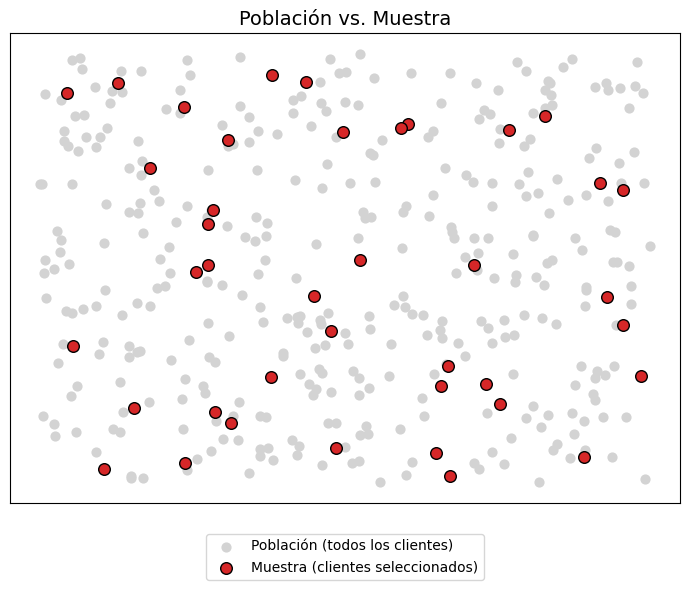

In [ ]:
# Generamos una pequeña representación visual de "población vs. muestra"
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# Simulamos 400 puntos como si fueran "toda la población" de clientes
poblacion_x = np.random.uniform(0, 10, 400)
poblacion_y = np.random.uniform(0, 10, 400)

# Elegimos aleatoriamente 40 de esos puntos para representar "la muestra"
idx_muestra = np.random.choice(400, 40, replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(poblacion_x, poblacion_y, color="lightgray", label="Población (todos los clientes)", s=40)
ax.scatter(poblacion_x[idx_muestra], poblacion_y[idx_muestra], color="#d62728",
           label="Muestra (clientes seleccionados)", s=70, edgecolor="black")
ax.set_title("Población vs. Muestra", fontsize=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=1)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


**¿Qué hace el código anterior?** (línea por línea, para quien no tiene experiencia en Python)

- `import numpy as np`: carga la librería **NumPy**, la herramienta estándar en Python para trabajar con números y operaciones matemáticas vectorizadas. La renombramos `np` por convención (así lo verás en el 99% del código de ciencia de datos).
- `import matplotlib.pyplot as plt`: carga **Matplotlib**, la librería más usada para crear gráficos en Python. La renombramos `plt`.
- `np.random.seed(7)`: fija una "semilla" aleatoria. Esto garantiza que, aunque el código genere números "al azar", **siempre obtengas los mismos resultados** cada vez que ejecutes la celda. Es clave para la reproducibilidad de un análisis.
- `np.random.uniform(0, 10, 400)`: genera 400 números aleatorios, todos entre 0 y 10, con la misma probabilidad de salir en cualquier punto de ese rango (distribución uniforme).
- `np.random.choice(400, 40, replace=False)`: elige 40 índices al azar, sin repetir (`replace=False`), de entre los 400 disponibles. Así simulamos el proceso de **muestreo**.
- `fig, ax = plt.subplots(...)`: crea el "lienzo" (`fig`) y los "ejes" (`ax`) donde se dibuja el gráfico.
- `ax.scatter(...)`: dibuja un gráfico de dispersión (puntos).
- El resto de líneas (`set_title`, `legend`, `set_xticks`) son ajustes estéticos del gráfico.


### 💬 Preguntas de discusión

1. En el caso de urbanMX Rewards, ¿qué implicaciones prácticas tendría trabajar con una muestra mal seleccionada (por ejemplo, que solo incluya clientes que compraron por app y excluya a los de tienda física)? ¿Qué tipo de decisiones de negocio se verían afectadas?
2. Si el equipo de marketing de urbanMX te dice "en promedio nuestros clientes gastan $3,000 pesos al trimestre" y tú sabes que ese número viene de una muestra, ¿qué preguntas le harías antes de confiar en esa cifra para tomar una decisión de inversión en campañas?


---
# 2. Importancia del Análisis Descriptivo

## 2.1 ¿Por qué el análisis descriptivo es una etapa crucial en cualquier análisis estadístico?

El análisis descriptivo es, en términos simples, la **radiografía inicial de los datos**. Así como un médico no operaría sin antes revisar los signos vitales del paciente, un científico de datos no debería construir un modelo predictivo sin antes entender:

- ¿Qué variables tengo y de qué tipo son?
- ¿Cómo se distribuyen esas variables? ¿Hay valores extremos (outliers)?
- ¿Hay datos faltantes, errores de captura o inconsistencias?
- ¿Qué tan "típico" es un caso promedio, y qué tan dispersos son los casos alrededor de ese promedio?

Saltarse esta etapa es una de las causas más comunes de que un modelo falle en producción: no porque el algoritmo esté mal, sino porque **nadie entendió los datos antes de modelarlos**.

## 2.2 ¿Cómo establece el análisis descriptivo el tono para análisis más avanzados?

Piensa en el análisis descriptivo como el **cimiento** de una pirámide analítica:

1. **Análisis descriptivo** → ¿Qué pasó? (esta sesión)
2. **Análisis diagnóstico** → ¿Por qué pasó?
3. **Análisis predictivo** → ¿Qué es probable que pase?
4. **Análisis prescriptivo** → ¿Qué deberíamos hacer al respecto?

Cada nivel depende de que el anterior esté bien hecho. Si el análisis descriptivo está mal (por ejemplo, si no detectaste que el 30% de tus registros de edad son inválidos), cualquier modelo predictivo que construyas después heredará ese error, amplificado.

**Conexión con urbanMX:** antes de que el equipo de Analítica Avanzada construya un modelo de *churn* o de segmentación, primero necesita responder preguntas descriptivas: ¿cuánto gasta un cliente típico?, ¿qué tan dispersos están los niveles de satisfacción?, ¿el gasto se concentra en pocos clientes o está repartido de forma pareja? Esas respuestas **no solo informan el modelo futuro**: muchas veces, por sí solas, ya generan decisiones de negocio accionables (sin necesidad de un modelo complejo).


### 💬 Preguntas de discusión

1. Describe una situación (real o hipotética) en tu trabajo o industria donde una decisión importante se haya tomado **sin** un análisis descriptivo adecuado. ¿Qué salió mal o qué riesgo se corrió?
2. Si tuvieras que convencer a un gerente de negocio de que invierta tiempo del equipo en análisis descriptivo antes de "ir directo al modelo predictivo", ¿qué argumento usarías?


---
# 3. Tipos de Variables de Estudio

Clasificar correctamente una variable no es un ejercicio académico: **determina qué operaciones matemáticas tienen sentido, qué medidas descriptivas se pueden calcular y qué tipo de modelo se puede usar más adelante**. Calcular un "promedio" de códigos postales, por ejemplo, es matemáticamente posible pero conceptualmente absurdo.


## 3.1 Variables numéricas

Representan cantidades que se pueden medir y sobre las cuales tienen sentido operaciones aritméticas (sumar, promediar, etc.).

### 3.1.1 Numéricas continuas
Pueden tomar **cualquier valor dentro de un rango** (incluyendo decimales). Entre dos valores cualesquiera, siempre existe (en teoría) otro valor posible.


In [ ]:
temperaturas = [11.3, 23.4, 0, 33.2, 25.4]
alturas_cm = [171.3, 183.23, 156.34, 164.34]

print("Ejemplo de variable numérica continua — temperatura (°C):", temperaturas)
print("Ejemplo de variable numérica continua — estatura (cm):", alturas_cm)


Ejemplo de variable numérica continua — temperatura (°C): [11.3, 23.4, 0, 33.2, 25.4]
Ejemplo de variable numérica continua — estatura (cm): [171.3, 183.23, 156.34, 164.34]


**Explicación del código:** `temperaturas` y `alturas_cm` son **listas** de Python (una estructura que guarda varios valores en un orden específico, entre corchetes `[ ]`). La función `print()` simplemente muestra el contenido en pantalla.

### 3.1.2 Numéricas discretas
Solo pueden tomar **valores específicos, generalmente enteros**, resultado de un conteo. No existen valores "intermedios" con sentido (no puedes tener 2.5 hijos).


In [ ]:
hijos = [1, 2, 6, 4, 3]
carros_en_estacionamiento = [0, 25, 34, 16, 10, 5]

print("Ejemplo de variable numérica discreta — número de hijos:", hijos)
print("Ejemplo de variable numérica discreta — carros en un estacionamiento:", carros_en_estacionamiento)


Ejemplo de variable numérica discreta — número de hijos: [1, 2, 6, 4, 3]
Ejemplo de variable numérica discreta — carros en un estacionamiento: [0, 25, 34, 16, 10, 5]


## 3.2 Variables categóricas (o cualitativas)

Representan categorías, etiquetas o atributos, no cantidades. No tiene sentido calcular un "promedio" directamente sobre ellas.

### 3.2.1 Categóricas nominales
Las categorías **no tienen un orden inherente**. Ninguna categoría es "mayor" o "menor" que otra.


In [ ]:
colores = ["azul", "rojo", "amarillo", "verde"]
animales = ["Perros", "Gatos", "Tigres", "Leones", "Conejos"]

print("Ejemplo de variable categórica nominal — colores:", colores)
print("Ejemplo de variable categórica nominal — animales:", animales)


Ejemplo de variable categórica nominal — colores: ['azul', 'rojo', 'amarillo', 'verde']
Ejemplo de variable categórica nominal — animales: ['Perros', 'Gatos', 'Tigres', 'Leones', 'Conejos']


### 3.2.2 Categóricas ordinales
Las categorías **sí tienen un orden o jerarquía natural**, aunque la distancia entre categorías no necesariamente sea numéricamente uniforme.


In [ ]:
nivel_satisfaccion = ["baja", "media", "alta"]
nivel_educativo = ["Primaria", "Bachillerato", "Pregrado", "Posgrado"]

print("Ejemplo de variable categórica ordinal — nivel de satisfacción:", nivel_satisfaccion)
print("Ejemplo de variable categórica ordinal — nivel educativo:", nivel_educativo)


Ejemplo de variable categórica ordinal — nivel de satisfacción: ['baja', 'media', 'alta']
Ejemplo de variable categórica ordinal — nivel educativo: ['Primaria', 'Bachillerato', 'Pregrado', 'Posgrado']


**Nota importante para el análisis:** con una variable ordinal como el nivel educativo, sí tiene sentido hablar de "mayor o menor que" (Posgrado > Pregrado), pero **no** de sumar o promediar directamente, a menos que la codifiques numéricamente de forma justificada (esto lo veremos con más detalle en sesiones futuras sobre codificación de variables).


## 3.3 Construyendo el caso de estudio: el dataset de urbanMX Rewards

Ahora sí, vamos a construir la base de datos simulada que usaremos durante el resto de la sesión. Simularemos **1,200 clientes** del programa de lealtad, con variables que representan cada uno de los tipos que acabamos de estudiar.


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)  # fijamos la semilla para que el ejemplo sea reproducible en clase

n_clientes = 1200

# --- Variables categóricas
genero = np.random.choice(["Femenino", "Masculino"], size=n_clientes, p=[0.55, 0.45])

canal_preferido = np.random.choice(
    ["Tienda física", "App móvil", "Sitio web"],
    size=n_clientes, p=[0.45, 0.35, 0.20]
)

categoria_principal = np.random.choice(
    ["Electrónica", "Hogar", "Moda", "Motos", "Servicios financieros"],
    size=n_clientes, p=[0.25, 0.20, 0.25, 0.15, 0.15]
)

ciudad = np.random.choice(
    ["CDMX", "Guadalajara", "Monterrey", "Puebla", "Tijuana"],
    size=n_clientes, p=[0.35, 0.20, 0.20, 0.15, 0.10]
)


nivel_membresia = np.random.choice(
    ["Bronce", "Plata", "Oro", "Diamante"],
    size=n_clientes, p=[0.45, 0.30, 0.18, 0.07]
)

satisfaccion = np.random.choice(
    ["Baja", "Media", "Alta", "Muy alta"],
    size=n_clientes, p=[0.08, 0.22, 0.45, 0.25]
)

# --- Variables numéricas
compras_trimestre = np.random.poisson(lam=3, size=n_clientes) + 1


edad = np.random.normal(loc=38, scale=12, size=n_clientes).clip(18, 80).round(0)

# El gasto trimestral lo simulamos con una distribución log-normal, típica en variables de
# gasto/ingreso: la mayoría de clientes gasta montos moderados, pero hay una "cola larga"
# de clientes que gastan mucho más que el resto.
gasto_trimestre = np.random.lognormal(mean=7.2, sigma=0.9, size=n_clientes)

# Simulamos un pequeño grupo de clientes "VIP" con gasto extraordinariamente alto.
# Esto es intencional: nos servirá más adelante para discutir el efecto de los outliers
# sobre la media, el sesgo y la elección de visualizaciones.
idx_vip = np.random.choice(n_clientes, size=15, replace=False)
gasto_trimestre[idx_vip] *= 8
gasto_trimestre = gasto_trimestre.round(2)

df = pd.DataFrame({
    "cliente_id": range(1, n_clientes + 1),
    "edad": edad,
    "genero": genero,
    "ciudad": ciudad,
    "canal_preferido": canal_preferido,
    "categoria_principal": categoria_principal,
    "nivel_membresia": nivel_membresia,
    "compras_trimestre": compras_trimestre,
    "gasto_trimestre_mxn": gasto_trimestre,
    "satisfaccion": satisfaccion,
})

df.head()


,cliente_id,edad,genero,ciudad,canal_preferido,categoria_principal,nivel_membresia,compras_trimestre,gasto_trimestre_mxn,satisfaccion
0,1,23.0,Femenino,CDMX,App móvil,Hogar,Bronce,3,2208.34,Alta
1,2,43.0,Masculino,Monterrey,Tienda física,Electrónica,Bronce,3,774.63,Media
2,3,42.0,Masculino,CDMX,Tienda física,Hogar,Oro,3,2989.88,Muy alta
3,4,42.0,Masculino,CDMX,Tienda física,Hogar,Bronce,4,1629.96,Alta
4,5,34.0,Femenino,CDMX,App móvil,Moda,Oro,3,1027.37,Media


**Explicación del código anterior** (clave para quienes no tienen experiencia en Python):

- `import pandas as pd`: carga **pandas**, la librería estándar de Python para trabajar con datos tabulares (como una hoja de cálculo, pero programable). Su estructura principal es el **DataFrame** (una tabla con filas y columnas).
- `np.random.choice(lista, size=n, p=[...])`: elige aleatoriamente `n` elementos de `lista`. El argumento `p` define la **probabilidad** de que salga cada opción (por eso los valores de `p` deben sumar 1). Así simulamos, por ejemplo, que el 45% de los clientes prefiere comprar en tienda física.
- `np.random.poisson(lam=3, size=n)`: genera números aleatorios siguiendo una **distribución de Poisson**, que es la distribución natural para "conteos" (número de compras, número de llamadas, etc.) cuando ocurren de forma independiente a una tasa promedio (`lam`).
- `np.random.normal(loc=38, scale=12, size=n)`: genera números siguiendo una **distribución normal** (campana de Gauss) con media (`loc`) de 38 y desviación estándar (`scale`) de 12 — así simulamos la edad de los clientes.
- `.clip(18, 80)`: "recorta" los valores para que ninguno quede por debajo de 18 ni por encima de 80 (evita edades imposibles como -3 o 130 años).
- `np.random.lognormal(mean=7.2, sigma=0.9, size=n)`: genera números con **distribución log-normal**, muy usada para modelar variables de dinero (ingreso, gasto), porque a diferencia de la normal, no permite valores negativos y tiene una cola derecha larga (unos pocos clientes gastan mucho más que el resto) — un patrón muy realista en negocios.
- `pd.DataFrame({...})`: construye la tabla final a partir de un diccionario, donde cada llave (`"edad"`, `"genero"`, etc.) se convierte en una columna.
- `df.head()`: muestra las primeras 5 filas del DataFrame, útil para "echar un primer vistazo" a los datos.


## 3.4 Clasificando cada variable del dataset urbanMX

Antes de calcular cualquier medida, clasifiquemos formalmente cada columna del dataset. Esta tabla es, en sí misma, un entregable típico de la etapa de análisis descriptivo en un proyecto real:

| Variable | Tipo | Subtipo |
|---|---|---|
| `edad` | Numérica | Continua (aunque se reporte en años enteros, conceptualmente es continua) |
| `genero` | Categórica | Nominal |
| `ciudad` | Categórica | Nominal |
| `canal_preferido` | Categórica | Nominal |
| `categoria_principal` | Categórica | Nominal |
| `nivel_membresia` | Categórica | **Ordinal** (Bronce < Plata < Oro < Diamante) |
| `compras_trimestre` | Numérica | Discreta |
| `gasto_trimestre_mxn` | Numérica | Continua |
| `satisfaccion` | Categórica | **Ordinal** (Baja < Media < Alta < Muy alta) |


In [ ]:
# Podemos verificar los tipos de dato que pandas detectó automáticamente:
df.dtypes


,0
cliente_id,int64
edad,float64
genero,object
ciudad,object
canal_preferido,object
categoria_principal,object
nivel_membresia,object
compras_trimestre,int64
gasto_trimestre_mxn,float64
satisfaccion,object


**Explicación:** `df.dtypes` muestra el tipo de dato que pandas asignó a cada columna (`object` para texto/categóricas, `int64` para enteros, `float64` para decimales). Es importante notar que **pandas no distingue automáticamente entre nominal y ordinal**: eso es una decisión conceptual que como analistas debemos aplicar nosotros, típicamente definiendo un orden explícito en el código cuando sea relevante (por ejemplo, al graficar o modelar `nivel_membresia`).


### 💬 Preguntas de discusión

1. Si `nivel_membresia` se guardara en el sistema como un número (1 = Bronce, 2 = Plata, 3 = Oro, 4 = Diamante), ¿qué error de interpretación podría cometer alguien que la trate como si fuera una variable numérica continua (por ejemplo, calculando su promedio y diciendo "el nivel de membresía promedio es 2.3")?
2. La variable `ciudad` tiene 5 categorías. Si urbanMX quisiera lanzar una campaña de retención distinta para cada ciudad, ¿qué información adicional (más allá del tipo de variable) necesitarías para decidir si esa segmentación tiene sentido estadístico y de negocio?
3. ¿Por qué crees que simulamos `compras_trimestre` con una distribución de Poisson y `gasto_trimestre_mxn` con una log-normal, en lugar de usar una distribución normal para ambas? Piensa en las restricciones naturales de cada variable (¿puede una variable de conteo ser negativa? ¿puede ser decimal?).


---
# 4. Medidas de Tendencia Central

Las medidas de tendencia central buscan responder una pregunta aparentemente simple: **¿cuál es el valor "típico" o "representativo" de mis datos?** Como veremos, la respuesta depende de *qué* medida uses, y elegir mal puede llevar a decisiones de negocio equivocadas.

## 4.1 Media (promedio aritmético)

**Definición formal:** la media es la suma de todos los valores dividida entre el número total de observaciones.

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

**Propiedad clave (y su talón de Aquiles):** la media usa **toda la información** de los datos (cada valor influye en el resultado), pero por eso mismo es **muy sensible a valores extremos (outliers)**. Un solo valor atípico puede desplazar la media de forma importante.


In [ ]:
data_simple = [10, 20, 30, 40, 50]
media_simple = np.mean(data_simple)
print("Media:", media_simple)


Media: 30.0


**Explicación:** `np.mean(lista)` es la función de NumPy que calcula la media aritmética de una lista o arreglo de números.

## 4.2 Mediana

**Definición formal:** es el valor que ocupa la posición central de los datos **ordenados**. Si el número de observaciones ($n$) es impar, es el valor central; si es par, es el promedio de los dos valores centrales.

$$\text{Mediana} = \begin{cases} x_{\left(\frac{n+1}{2}\right)} & \text{si } n \text{ es impar} \\[4pt] \dfrac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2} & \text{si } n \text{ es par} \end{cases}$$

**Propiedad clave:** la mediana **no** se ve afectada por valores extremos, porque solo depende de la posición central de los datos ordenados, no de su magnitud. Es una medida **robusta**.


In [ ]:
mediana_simple = np.median(data_simple)
print("Mediana:", mediana_simple)


Mediana: 30.0


**Explicación:** `np.median(lista)` calcula la mediana. Internamente, NumPy ordena los datos y aplica la fórmula anterior — tú no necesitas ordenarlos manualmente.

## 4.3 Moda

**Definición formal:** es el valor (o los valores) que aparece con mayor frecuencia en el conjunto de datos. Es la única medida de tendencia central que **también se puede calcular para variables categóricas**.


In [ ]:
from statistics import mode

data_con_repetidos = [10, 20, 30, 20, 40, 20, 50]
moda_simple = mode(data_con_repetidos)
print("Moda:", moda_simple)


Moda: 20


**Explicación:** `from statistics import mode` importa la función `mode()` de la librería estándar `statistics` de Python (distinta de NumPy). Esta función retorna el valor más frecuente en la lista.


## 4.4 Aplicación al caso urbanMX: ¿cuál es el gasto "típico" de un cliente?

Vamos a calcular las tres medidas sobre `gasto_trimestre_mxn`, la variable que simulamos con una cola larga de clientes VIP. Esto nos va a permitir ver, con datos reales del caso, por qué la elección de la medida importa.


In [ ]:
media_gasto = df["gasto_trimestre_mxn"].mean()
mediana_gasto = df["gasto_trimestre_mxn"].median()
moda_gasto = df["gasto_trimestre_mxn"].round(0).mode()[0]  # redondeamos porque en variables continuas la moda exacta casi no se repite

print(f"Media del gasto trimestral:   ${media_gasto:,.2f} MXN")
print(f"Mediana del gasto trimestral: ${mediana_gasto:,.2f} MXN")
print(f"Moda del gasto trimestral (redondeada): ${moda_gasto:,.2f} MXN")


Media del gasto trimestral:   $2,263.62 MXN
Mediana del gasto trimestral: $1,319.75 MXN
Moda del gasto trimestral (redondeada): $957.00 MXN


**Explicación del código:**
- `df["gasto_trimestre_mxn"]` selecciona una sola columna del DataFrame (se le llama **Serie** en pandas).
- `.mean()`, `.median()`, `.mode()` son **métodos** de pandas (funciones que "pertenecen" al objeto) equivalentes a `np.mean()`, `np.median()` y `mode()`, pero ya integrados directamente en el DataFrame — así no necesitas convertir la columna a lista primero.
- `.mode()[0]` toma el primer valor de la moda (puede haber más de uno si hay empate en la frecuencia).
- `f"...${valor:,.2f}..."` es un **f-string** (cadena con formato): el `:,.2f` da formato de número con separador de miles (`,`) y 2 decimales — muy útil para reportar cifras de dinero de forma legible.

**Interpretación de negocio:** si la media es notablemente mayor que la mediana, es una señal de que hay un grupo pequeño de clientes con gasto muy alto (nuestros clientes VIP) que está "jalando" el promedio hacia arriba. En ese caso, **reportar solo la media al equipo de marketing sería engañoso**: haría parecer que el cliente "típico" gasta más de lo que realmente gasta la mayoría.


In [ ]:
diferencia_pct = (media_gasto - mediana_gasto) / mediana_gasto * 100
print(f"La media supera a la mediana en un {diferencia_pct:.1f}%")


La media supera a la mediana en un 71.5%


### 💬 Preguntas de discusión

1. Con base en los resultados anteriores, si fueras tú quien presenta el reporte trimestral al Comité Directivo de urbanMX, ¿reportarías la media, la mediana, o ambas? Justifica tu respuesta pensando en qué decisión tomaría el comité con cada cifra.
2. Los clientes VIP representan solo 15 de 1,200 clientes (1.25%), pero afectan visiblemente la media. ¿En qué otras variables de negocio (fuera de este caso) has visto o esperarías ver un fenómeno similar, donde "pocos casos" distorsionan el promedio general?
3. ¿Qué haría el equipo de urbanMX si, en lugar de reportar un solo número, decidiera reportar la media **excluyendo** a los clientes VIP, y por separado un análisis específico del segmento VIP? ¿Qué ventajas y riesgos tiene esa estrategia?


---
# 5. Medidas de Dispersión

Conocer el "centro" de los datos no es suficiente. Dos conjuntos de datos pueden tener exactamente la misma media, pero comportamientos radicalmente distintos si uno está muy concentrado alrededor de ese centro y el otro muy disperso. Las medidas de dispersión cuantifican **qué tan lejos, en promedio, están los datos de su valor central**.

## 5.1 Rango

**Definición formal:** la diferencia entre el valor máximo y el valor mínimo del conjunto de datos.

$$\text{Rango} = \max(x_i) - \min(x_i), \quad 1 \leq i \leq n$$

Es la medida de dispersión más simple, pero también la más frágil: depende **únicamente** de los dos valores extremos e ignora por completo cómo se distribuye el resto de los datos.


In [ ]:
rango_simple = max(data_simple) - min(data_simple)
print("Rango:", rango_simple)


Rango: 40


## 5.2 Varianza

**Definición formal:** el promedio de las diferencias al cuadrado entre cada valor y la media. Se eleva al cuadrado para que las desviaciones positivas y negativas no se cancelen entre sí.

$$\text{Var}(x) = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n}$$

**Nota técnica:** esta es la fórmula de la varianza **poblacional**. Cuando trabajamos con una muestra y queremos **estimar** la varianza poblacional, se usa un divisor de $n-1$ en lugar de $n$ (la llamada *corrección de Bessel*), lo cual produce un estimador insesgado. Volveremos a este matiz cuando lleguemos a inferencia estadística.


In [ ]:
varianza_simple = np.var(data_simple)
print("Varianza (poblacional, ddof=0 por defecto en NumPy):", varianza_simple)


Varianza (poblacional, ddof=0 por defecto en NumPy): 200.0


## 5.3 Desviación estándar

**Definición formal:** es la raíz cuadrada de la varianza. Se usa con más frecuencia que la varianza porque **está en las mismas unidades que la variable original** (mientras que la varianza queda en unidades al cuadrado, difíciles de interpretar).

$$\text{std}(x) = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n}}$$


In [ ]:
std_simple = np.std(data_simple)
print("Desviación estándar:", std_simple)


Desviación estándar: 14.142135623730951


**Explicación de las tres celdas anteriores:** `max()` y `min()` son funciones nativas de Python. `np.var()` y `np.std()` son funciones de NumPy que implementan directamente las fórmulas matemáticas de varianza y desviación estándar, respectivamente — no necesitas programar la sumatoria manualmente.

## 5.4 Coeficiente de variación (una medida adicional, útil para comparar dispersión entre grupos)

**Definición formal:** es la desviación estándar expresada como proporción de la media. Al ser una medida **relativa** (sin unidades), permite comparar la dispersión de variables con escalas distintas, o de un mismo grupo en distintos contextos.

$$CV = \frac{\text{std}(x)}{\bar{x}} \times 100\%$$

Esto es especialmente útil en negocio: decir "la desviación estándar del gasto es de $1,800 MXN" no dice mucho por sí sola, pero decir "el gasto varía un 60% respecto a su propia media" sí permite comparar, por ejemplo, la dispersión relativa del gasto contra la dispersión relativa de la edad, aunque estén en escalas totalmente distintas (pesos vs. años).


## 5.5 Aplicación al caso urbanMX: ¿el gasto se comporta igual en todos los niveles de membresía?

Vamos a comparar la dispersión del gasto trimestral **entre** los distintos niveles de membresía. Esto es exactamente el tipo de pregunta que un equipo de lealtad haría antes de diseñar beneficios diferenciados.


In [ ]:
# Definimos el orden lógico (ordinal) de la membresía para que las tablas y gráficos lo respeten
orden_membresia = ["Bronce", "Plata", "Oro", "Diamante"]
df["nivel_membresia"] = pd.Categorical(df["nivel_membresia"], categories=orden_membresia, ordered=True)

resumen_dispersión = df.groupby("nivel_membresia", observed=True)["gasto_trimestre_mxn"].agg(
    media="mean",
    desviacion_estandar="std",
    minimo="min",
    maximo="max"
)

# Calculamos el coeficiente de variación (CV) para cada grupo
resumen_dispersión["coef_variacion_%"] = (
    resumen_dispersión["desviacion_estandar"] / resumen_dispersión["media"] * 100
).round(1)

resumen_dispersión.round(2)


,media,desviacion_estandar,minimo,maximo,coef_variacion_%
nivel_membresia,,,,,
Bronce,2269.19,3185.08,82.41,45589.87,140.4
Plata,2190.02,4055.81,45.53,51922.41,185.2
Oro,2167.66,3546.95,59.81,40067.82,163.6
Diamante,2719.01,4921.05,231.09,43459.39,181.0


**Explicación del código (nuevo para quienes no programan en Python):**

- `pd.Categorical(columna, categories=[...], ordered=True)`: convierte una columna de texto en una **variable categórica ordenada** dentro de pandas. Esto es justo la operación que discutimos en la Sección 3: le decimos explícitamente a Python que "Bronce < Plata < Oro < Diamante", algo que pandas no puede adivinar solo.
- `df.groupby("nivel_membresia")`: agrupa las filas del DataFrame según los valores de `nivel_membresia` (es decir, junta a todos los clientes Bronce, luego a todos los Plata, etc.). Es el equivalente en código a una **tabla dinámica** de Excel.
- `["gasto_trimestre_mxn"].agg(...)`: sobre cada grupo, calcula varias métricas de la columna de gasto al mismo tiempo. El argumento `observed=True` evita que pandas muestre combinaciones vacías.
- `.agg(media="mean", desviacion_estandar="std", ...)`: cada argumento define el nombre de una columna nueva (a la izquierda) y qué operación aplicar (a la derecha, como texto).

**Interpretación de negocio:** presta atención no solo a la media de cada grupo (que probablemente aumenta con el nivel de membresía, algo esperable), sino especialmente al **coeficiente de variación**. Un grupo con CV alto significa que, aunque su gasto promedio sea alto, hay mucha heterogeneidad interna — es decir, "Diamante" no es necesariamente un grupo homogéneo de clientes similares.


### 💬 Preguntas de discusión

1. Si el nivel Diamante tiene el coeficiente de variación más alto de los cuatro grupos, ¿qué implicaría eso para una estrategia de beneficios "iguales para todos" dentro de ese nivel? ¿Recomendarías subsegmentar ese grupo?
2. Compara el rango con la desviación estándar para el gasto trimestral general (sin agrupar). ¿Por qué el rango podría dar una impresión exageradamente alta de la dispersión "típica" del gasto, dado lo que ya sabemos sobre los clientes VIP?
3. Si urbanMX quisiera comparar qué tan dispersa es la **edad** de sus clientes frente a qué tan disperso es su **gasto**, ¿por qué no sería correcto comparar directamente sus desviaciones estándar (en años vs. en pesos)? ¿Qué medida de esta sección resolvería ese problema?


---
# 6. Medidas de Sesgo y Curtosis

Hasta ahora hemos descrito el **centro** (tendencia central) y el **ancho** (dispersión) de una distribución. Nos falta describir su **forma**: ¿es simétrica? ¿tiene una cola más larga de un lado? ¿es más puntiaguda o más aplanada que una distribución normal? Estas preguntas son exactamente las que responden el sesgo y la curtosis.

## 6.1 Sesgo (asimetría)

**Definición formal:** el sesgo mide el grado en que una distribución se desvía de ser simétrica alrededor de su media.

$$\text{Sesgo} = \frac{\sum_{i=1}^n (x_i - \bar{x})^3}{n \cdot \text{std}^3}$$

**Cómo interpretarlo:**

- **Sesgo ≈ 0**: distribución aproximadamente simétrica (como la campana de Gauss).
- **Sesgo > 0 (positivo)**: la distribución tiene una **cola más larga hacia la derecha**. Suele ocurrir cuando hay un grupo pequeño de valores muy altos (exactamente el patrón que vimos con `gasto_trimestre_mxn`).
- **Sesgo < 0 (negativo)**: la distribución tiene una **cola más larga hacia la izquierda**.


In [ ]:
from scipy.stats import skew

data_sesgo_ejemplo = [10, 20, 30, 40, 50, 60, 71]
sesgo_ejemplo = skew(data_sesgo_ejemplo)
print("Sesgo:", sesgo_ejemplo)


Sesgo: 0.02705769434262354


**Explicación:** `from scipy.stats import skew` importa la función `skew()` de **SciPy**, una librería de cómputo científico que complementa a NumPy con funciones estadísticas más especializadas.

## 6.2 Curtosis

**Definición formal:** la curtosis mide qué tan "puntiaguda" o "aplanada" es una distribución en comparación con la distribución normal, y en particular, qué tan pesadas son sus colas (es decir, qué tan frecuentes son los valores extremos).

$$\text{Curtosis} = \frac{\sum_{i=1}^n (x_i - \bar{x})^4}{n \cdot \text{std}^4} - 3$$

El "$-3$" al final convierte la medida en **exceso de curtosis**: así, una distribución normal tiene un valor de referencia de 0 (en lugar de 3).

- **Curtosis ≈ 0**: forma similar a la normal (mesocúrtica).
- **Curtosis > 0**: colas más pesadas que la normal — más valores extremos de lo esperado (leptocúrtica).
- **Curtosis < 0**: colas más ligeras, distribución más "aplanada" (platicúrtica).


In [ ]:
from scipy.stats import kurtosis

data_curtosis_ejemplo = [10, 20, 30, 40, 50, 60, 70]
curtosis_ejemplo = kurtosis(data_curtosis_ejemplo)  # por defecto, SciPy ya retorna el EXCESO de curtosis
print("Curtosis (exceso, referencia normal = 0):", curtosis_ejemplo)


Curtosis (exceso, referencia normal = 0): -1.25


**Explicación:** igual que con `skew`, `kurtosis()` viene de SciPy. Por defecto, SciPy calcula directamente el **exceso de curtosis** (ya resta 3 internamente cuando `fisher=True`, que es el valor por defecto).


## 6.3 Aplicación al caso urbanMX: cuantificando lo que ya sospechábamos del gasto

En la Sección 4 detectamos, de forma cualitativa, que la media del gasto era mayor que la mediana — señal de asimetría positiva. Ahora lo cuantificamos formalmente.


In [ ]:
sesgo_gasto = skew(df["gasto_trimestre_mxn"])
curtosis_gasto = kurtosis(df["gasto_trimestre_mxn"])

print(f"Sesgo del gasto trimestral:    {sesgo_gasto:.2f}")
print(f"Curtosis (exceso) del gasto:   {curtosis_gasto:.2f}")


Sesgo del gasto trimestral:    7.44
Curtosis (exceso) del gasto:   76.38


**Interpretación de negocio:** un sesgo marcadamente positivo (mayor a 1, digamos) confirma numéricamente lo que veníamos discutiendo: la distribución del gasto tiene una cola derecha larga. Una curtosis alta, adicionalmente, nos dice que los valores extremos (los clientes VIP) no son solo "un poco más altos" que el resto, sino que representan una desviación considerable respecto a lo que esperaríamos de una distribución normal.

Esto tiene una consecuencia **muy concreta para el resto del curso**: varios modelos estadísticos clásicos (por ejemplo, la regresión lineal en su forma más simple) asumen que ciertas variables se comportan de forma aproximadamente normal. Si el sesgo y la curtosis de una variable como el gasto son altos, **eso ya nos anticipa que probablemente necesitaremos una transformación de la variable** (por ejemplo, aplicar logaritmo) antes de usarla en algunos modelos — un tema que retomaremos en sesiones futuras.


### 💬 Preguntas de discusión

1. Con el sesgo y la curtosis que calculamos, ¿cambiarías tu recomendación de la Sección 4 sobre si reportar la media o la mediana del gasto al Comité Directivo? ¿Por qué?
2. Si en lugar del gasto trimestral analizáramos la **edad** de los clientes (que simulamos con una distribución normal), ¿qué esperarías encontrar en el sesgo y la curtosis? Antes de calcularlo, escribe tu predicción y luego verifícala en la celda de código siguiente.
3. ¿Qué tipo de decisiones (de producto, de riesgo, de pricing) podrían salir mal si un equipo de datos ignora que una variable financiera tiene sesgo alto y la trata como si fuera simétrica?


In [ ]:
# Verificación de la predicción del punto 2: sesgo y curtosis de la edad
print(f"Sesgo de la edad:    {skew(df['edad']):.2f}")
print(f"Curtosis de la edad: {kurtosis(df['edad']):.2f}")


Sesgo de la edad:    0.23
Curtosis de la edad: -0.39


---
# 7. Visualización de Datos

Las medidas numéricas que calculamos son precisas, pero **una buena visualización comunica en segundos lo que un conjunto de números tarda minutos en explicar**. Además, algunos patrones (multimodalidad, agrupaciones, outliers) son mucho más fáciles de detectar visualmente que numéricamente.

## 7.1 Histograma

Divide el rango de una variable numérica en intervalos ("bins") y cuenta cuántas observaciones caen en cada uno. Es la herramienta principal para ver la **forma de una distribución** (y confirmar visualmente el sesgo y la curtosis que calculamos).


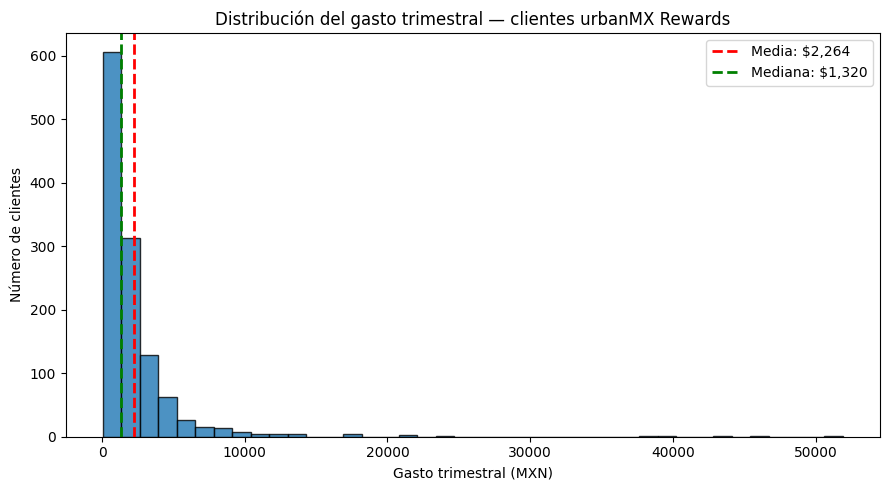

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["gasto_trimestre_mxn"], bins=40, color="#1f77b4", edgecolor="black", alpha=0.8)

media_g = df["gasto_trimestre_mxn"].mean()
mediana_g = df["gasto_trimestre_mxn"].median()
ax.axvline(media_g, color="red", linestyle="--", linewidth=2, label=f"Media: ${media_g:,.0f}")
ax.axvline(mediana_g, color="green", linestyle="--", linewidth=2, label=f"Mediana: ${mediana_g:,.0f}")

ax.set_title("Distribución del gasto trimestral — clientes urbanMX Rewards")
ax.set_xlabel("Gasto trimestral (MXN)")
ax.set_ylabel("Número de clientes")
ax.legend()
plt.tight_layout()
plt.show()


**Explicación del código:**
- `ax.hist(columna, bins=40, ...)`: dibuja el histograma. `bins=40` define en cuántos intervalos se divide el rango de la variable — un número más alto da más detalle pero puede verse ruidoso; uno más bajo simplifica pero puede ocultar patrones.
- `ax.axvline(valor, ...)`: dibuja una línea vertical en un valor específico del eje X — la usamos para marcar visualmente dónde caen la media y la mediana sobre la distribución.
- Nota cómo, visualmente, la mayoría de las barras (clientes) se concentran a la izquierda, mientras que la cola se extiende mucho hacia la derecha: es la representación gráfica exacta del sesgo positivo que calculamos en la sección anterior.

## 7.2 Boxplot (diagrama de caja y bigotes)

Resume una variable numérica usando sus **cuartiles**: la caja va del percentil 25 al percentil 75 (el rango intercuartílico, donde está el 50% central de los datos), la línea dentro de la caja es la mediana, y los "bigotes" se extienden hasta un límite razonable, marcando los valores fuera de ese rango como posibles **outliers** (puntos individuales).


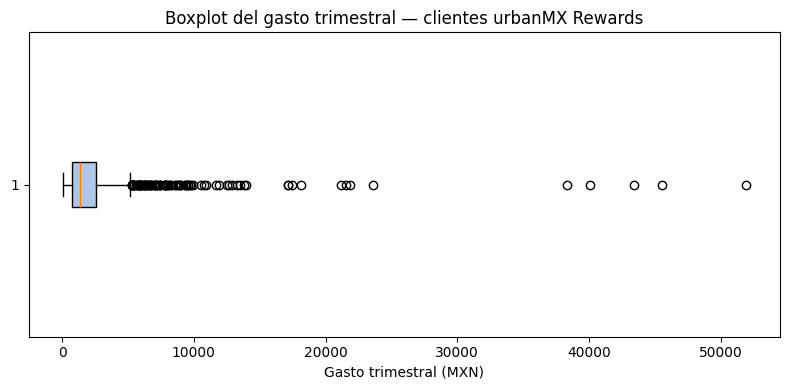

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(df["gasto_trimestre_mxn"], vert=False, patch_artist=True,
           boxprops=dict(facecolor="#aec7e8"))
ax.set_title("Boxplot del gasto trimestral — clientes urbanMX Rewards")
ax.set_xlabel("Gasto trimestral (MXN)")
plt.tight_layout()
plt.show()


**Explicación:** `ax.boxplot(columna, vert=False, ...)` dibuja el boxplot en orientación horizontal (`vert=False`). Los puntos que aparecen sueltos a la derecha de los "bigotes" son, precisamente, nuestros clientes VIP — el boxplot los identifica visualmente como valores atípicos, sin que nosotros tengamos que definir manualmente un umbral.

## 7.3 Gráfico de densidad (KDE)

Es una versión "suavizada" del histograma: en lugar de barras discretas, estima una curva continua que representa la distribución de probabilidad de la variable. Es útil para comparar la forma de varias distribuciones en un mismo gráfico sin que se estorben visualmente las barras.


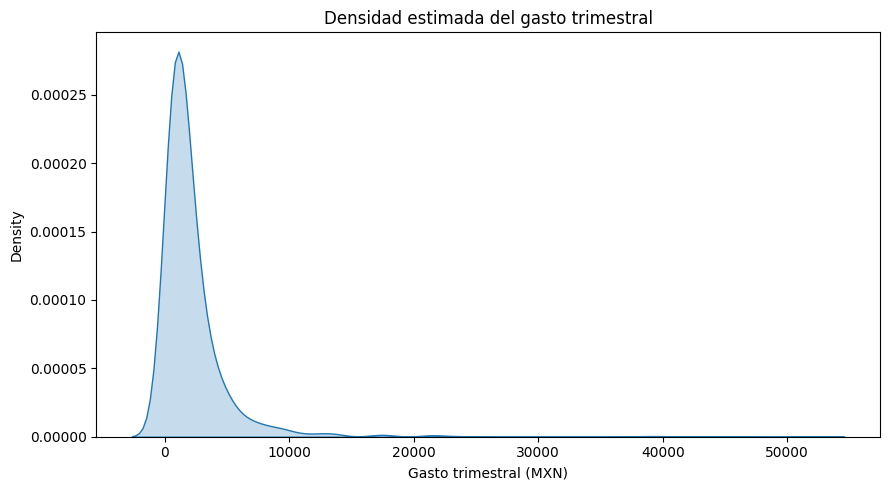

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(df["gasto_trimestre_mxn"], fill=True, color="#1f77b4", ax=ax)
ax.set_title("Densidad estimada del gasto trimestral")
ax.set_xlabel("Gasto trimestral (MXN)")
plt.tight_layout()
plt.show()


**Explicación:** `seaborn` (importado como `sns`) es una librería construida sobre Matplotlib, especializada en gráficos estadísticos con una sintaxis más simple. `sns.kdeplot(columna, fill=True, ...)` calcula y dibuja la curva de densidad, rellenando el área bajo la curva (`fill=True`) para facilitar la lectura visual.

## 7.4 Comparando distribuciones entre grupos: boxplot por categoría

Una de las visualizaciones más útiles en un contexto de negocio no es ver **una sola** distribución, sino comparar la misma variable **entre distintos grupos**. Retomemos la pregunta de la Sección 5: ¿cómo se compara el gasto entre niveles de membresía?


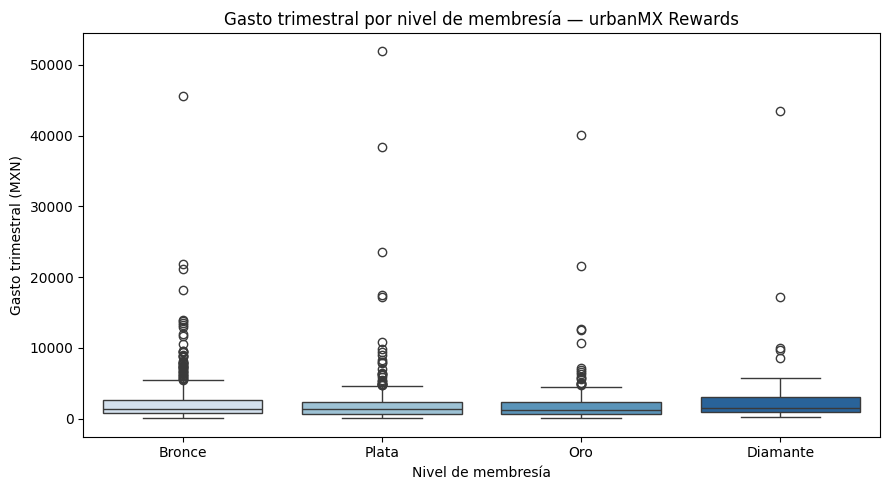

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="nivel_membresia", y="gasto_trimestre_mxn",
            order=orden_membresia, ax=ax, hue="nivel_membresia",
            palette="Blues", legend=False)
ax.set_title("Gasto trimestral por nivel de membresía — urbanMX Rewards")
ax.set_xlabel("Nivel de membresía")
ax.set_ylabel("Gasto trimestral (MXN)")
plt.tight_layout()
plt.show()


**Explicación:** `sns.boxplot(data=df, x="...", y="...", order=[...])` dibuja un boxplot por cada categoría de `x`, todos con la misma escala en `y`, lo que permite comparar visualmente la mediana, la dispersión y los outliers de cada grupo en un solo gráfico. El argumento `order` asegura que las cajas se muestren en el orden lógico de la membresía (Bronce → Diamante) y no en orden alfabético.

## 7.5 Panel integrador: los cuatro gráficos que resumen la sesión

Cerramos la sección de visualización juntando, en un solo panel, las piezas clave del análisis descriptivo que hicimos sobre `gasto_trimestre_mxn`.


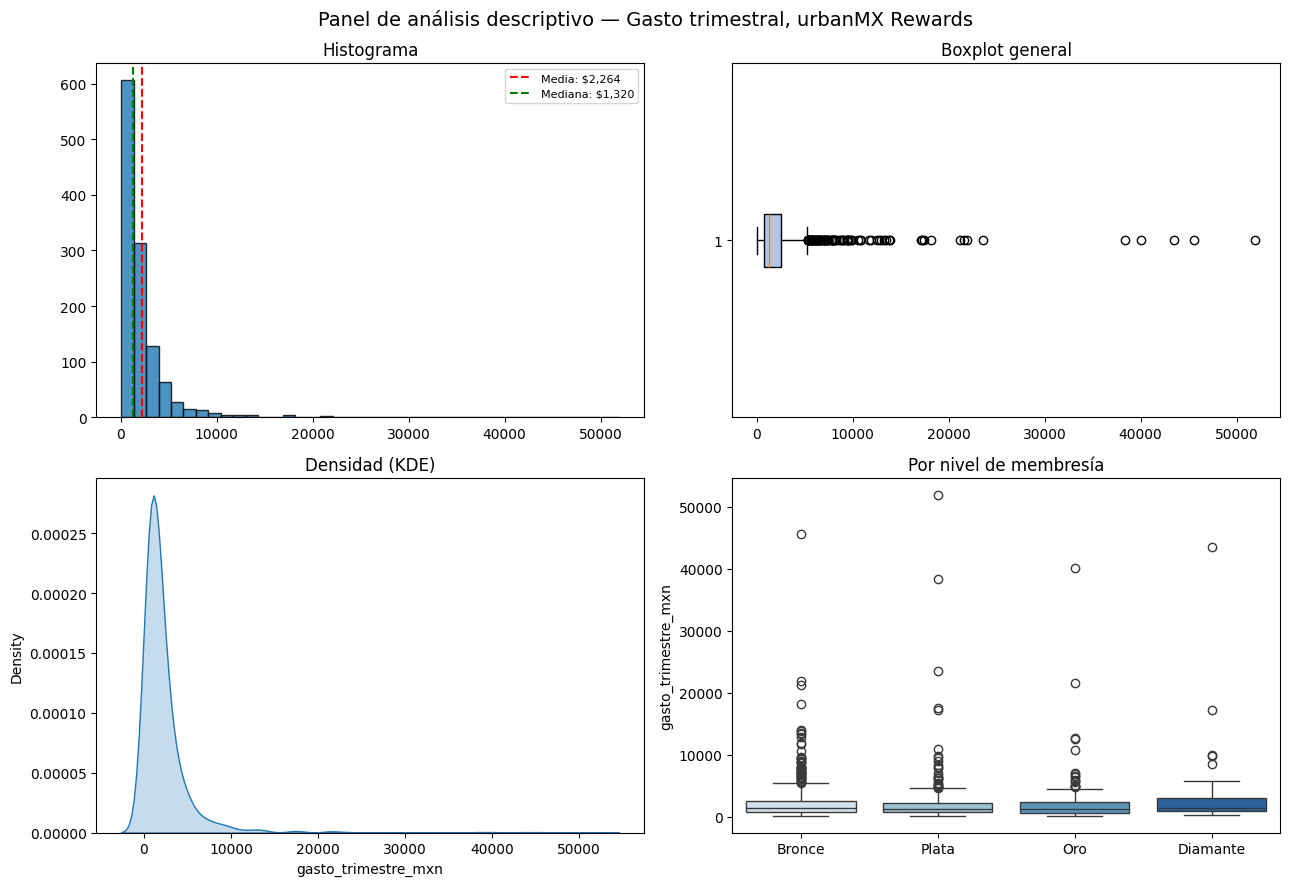

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Histograma con media y mediana
axes[0, 0].hist(df["gasto_trimestre_mxn"], bins=40, color="#1f77b4", edgecolor="black", alpha=0.8)
axes[0, 0].axvline(media_g, color="red", linestyle="--", label=f"Media: ${media_g:,.0f}")
axes[0, 0].axvline(mediana_g, color="green", linestyle="--", label=f"Mediana: ${mediana_g:,.0f}")
axes[0, 0].set_title("Histograma")
axes[0, 0].legend(fontsize=8)

# 2. Boxplot general
axes[0, 1].boxplot(df["gasto_trimestre_mxn"], vert=False, patch_artist=True,
                    boxprops=dict(facecolor="#aec7e8"))
axes[0, 1].set_title("Boxplot general")

# 3. Densidad (KDE)
sns.kdeplot(df["gasto_trimestre_mxn"], fill=True, color="#1f77b4", ax=axes[1, 0])
axes[1, 0].set_title("Densidad (KDE)")

# 4. Boxplot por nivel de membresía
sns.boxplot(data=df, x="nivel_membresia", y="gasto_trimestre_mxn", order=orden_membresia,
            ax=axes[1, 1], hue="nivel_membresia", palette="Blues", legend=False)
axes[1, 1].set_title("Por nivel de membresía")
axes[1, 1].set_xlabel("")

fig.suptitle("Panel de análisis descriptivo — Gasto trimestral, urbanMX Rewards", fontsize=14)
plt.tight_layout()
plt.show()


**Explicación:** `plt.subplots(2, 2, figsize=(13, 9))` crea una cuadrícula de 2 filas × 2 columnas de gráficos dentro de una misma figura; `axes` es un arreglo donde `axes[0, 0]` es la posición superior izquierda, `axes[1, 1]` la inferior derecha, y así sucesivamente. `fig.suptitle(...)` agrega un título general para todo el panel.


### 💬 Preguntas de discusión

1. Mirando el panel completo, si tuvieras que elegir **un solo gráfico** para presentarle al Comité Directivo de urbanMX (que tiene poco tiempo y no es técnico), ¿cuál elegirías y por qué? ¿Qué gráfico es más apropiado si en cambio le presentas al equipo técnico de analítica?
2. En el boxplot por nivel de membresía, ¿los outliers (clientes VIP) aparecen distribuidos en todos los niveles o se concentran en alguno en particular? ¿Qué implicación de negocio tiene ese patrón?
3. Si urbanMX decidiera excluir a los clientes VIP del histograma para "ver mejor" la distribución del resto de los clientes, ¿qué se ganaría y qué se perdería con esa decisión? ¿En qué tipo de reporte sería apropiado hacerlo y en cuál no?


---
# Cierre de la sesión

## Lo que vimos hoy

- Un vocabulario común: modelo, estadística, dato, información, población, muestra, parámetro y estadístico.
- Por qué el análisis descriptivo es el cimiento de cualquier análisis más avanzado.
- Cómo clasificar correctamente una variable (numérica continua/discreta, categórica nominal/ordinal), y por qué esa clasificación no es un tecnicismo sino una decisión que afecta todo el análisis posterior.
- Medidas de tendencia central (media, mediana, moda) y cómo su relación entre sí es diagnóstica de la forma de una distribución.
- Medidas de dispersión (rango, varianza, desviación estándar, coeficiente de variación) y cómo comparar dispersión entre grupos y entre variables de distinta escala.
- Medidas de sesgo y curtosis, que cuantifican formalmente lo que la comparación media-mediana ya nos insinuaba.
- Herramientas de visualización (histograma, boxplot, densidad) y cómo combinarlas en un panel para contar una historia completa de los datos.


